In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [4]:
np.random.seed(0)

# =====================================================
# MODEL : Wiener chaos <= 2
# =====================================================

beta1 = 0.5
beta2 = 0.3
gamma = 0.2

Var = beta1**2 + beta2**2 + gamma**2

S_star = np.array([
    beta1**2,
    beta2**2,
    gamma**2
]) / Var

print("True Sobol:", S_star)

# =====================================================
# Möbius inverse matrix
# order = ({1}, {2}, {1,2})
# M^{-1}_{u,v} = 1_{v ⊂ u}
# =====================================================

M_inv = np.array([
    [1,0,0],
    [0,1,0],
    [1,1,1]
], dtype=float)

# =====================================================
# Projection matrix
# =====================================================

B = np.array([
    [1, -1, 0],
    [1, 1, -2]
], dtype=float)

# orthonormalisation
Q, _ = np.linalg.qr(B.T)  
P = Q.T      # matrice 2x3 de projection

Var = beta1**2 + beta2**2 + gamma**2

H = (Var/3) * np.array([
    [2,1,1],
    [1,2,1],
    [1,1,1]
])

H_T = P @ H @ P.T
H_T_inv = np.linalg.inv(H_T)

True Sobol: [0.65789474 0.23684211 0.10526316]


In [5]:
def model(X):
    x1, x2 = X
    return beta1*x1 + beta2*x2 + gamma*x1*x2

def sample_X():
    return np.random.randn(2)


# =====================================================
# Pick-Freeze
# =====================================================

def pick_freeze(subset, X, Xp):

    X_pf = X.copy()

    if subset == 0:        # freeze X1
        X_pf[1] = Xp[1]

    elif subset == 1:      # freeze X2
        X_pf[0] = Xp[0]

    # subset 2 -> full set -> Y(U)=Y

    return model(X_pf)

def sample_xi(n_samples=500000):

    xis = []

    m = 0  # car Y est centré théoriquement

    for _ in range(n_samples):

        X = sample_X()
        Xp = sample_X()

        subset = np.random.choice([0,1,2])

        Y = model(X)
        Y_pf = pick_freeze(subset, X, Xp)

        MS = M_inv @ S_star

        grad = (Y-m) * M_inv[subset] * (
            (Y-m)*MS[subset] - (Y_pf-m)
        )

        xis.append(grad)

    xis = np.array(xis)

    Sigma = np.cov(xis.T)

    return Sigma


Sigma = sample_xi()

Sigma_T = P @ Sigma @ P.T
V = H_T_inv @ Sigma_T @ H_T_inv

In [20]:
def model(X):
    return beta1*X[:,0] + beta2*X[:,1] + gamma*X[:,0]*X[:,1]


def sample_X(size):
    return np.random.randn(size, 2)

def pick_freeze_vectorized(subset, X, Xp):

    X_new = X.copy()

    mask0 = subset == 0   # freeze X1 → replace X2
    mask1 = subset == 1   # freeze X2 → replace X1

    X_new[mask0, 1] = Xp[mask0, 1]
    X_new[mask1, 0] = Xp[mask1, 0]

    return model(X_new)

def mirror_descent_vectorized(n_runs=1000, n_iter=10000, eta0=10):

    # shape = (runs, dim)
    S = np.ones((n_runs, 3)) / 3
    S_avg = np.zeros_like(S)

    m = np.zeros(n_runs)

    subsets = np.arange(3)
    probs = np.ones(3)/3

    for t in range(1, n_iter+1):

        X = sample_X(size=n_runs)
        Xp = sample_X(size=n_runs)

        subset = np.random.choice(subsets, size=n_runs, p=probs)

        Y = model(X)
        Y_pf = pick_freeze_vectorized(subset, X, Xp)

        # running mean
        m += (Y - m)/t

        MS = S @ M_inv.T   # MUCH faster than looping

        grad = (
            (Y-m)[:,None]
            * M_inv[subset]
            * ((Y-m)[:,None] * MS[range(n_runs), subset][:,None]
               - (Y_pf-m)[:,None])
        )

        gamma_t = eta0 / t**0.501

        S *= np.exp(-gamma_t * grad)
        S /= S.sum(axis=1, keepdims=True)

        S_avg += (S - S_avg)/t

    return S_avg

def run_many_fast(n_runs=5000, n_iter=500000):

    S_polyak = mirror_descent_vectorized(n_runs, n_iter)

    err = np.sqrt(n_iter) * (S_polyak - S_star)

    Z = err @ P.T

    return Z

Z = run_many_fast()

# diagonaliser V
eigvals, eigvecs = np.linalg.eigh(V)
V_half = eigvecs @ np.diag(np.sqrt(eigvals))

# blanchiment
Z_white = np.linalg.solve(V_half, Z.T).T

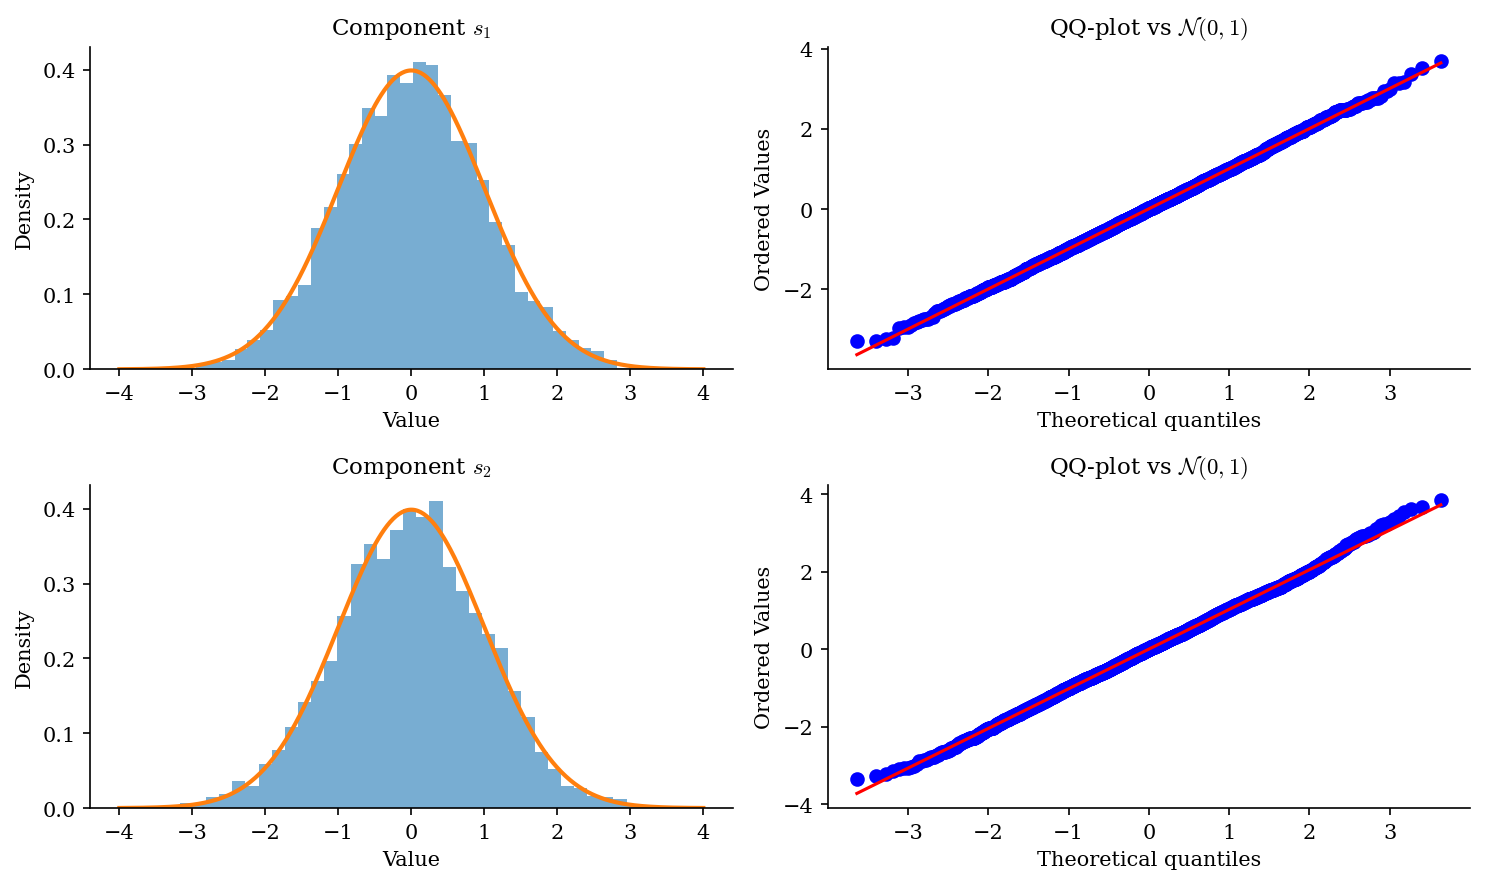

In [21]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10
})

fig, axes = plt.subplots(2, 2, figsize=(10,6), dpi=150)

x = np.linspace(-4, 4, 400)
gaussian_pdf = stats.norm.pdf(x, 0, 1)

for i in range(2):

    # -------- Histogramme --------
    ax_hist = axes[i, 0]

    ax_hist.hist(
        Z_white[:, i],
        bins=40,
        density=True,
        alpha=0.6
    )

    ax_hist.plot(
        x,
        gaussian_pdf,
        linewidth=2
    )

    ax_hist.set_title(rf"Component $s_{i+1}$", fontsize=11)
    ax_hist.set_xlabel("Value")
    ax_hist.set_ylabel("Density")

    # look minimaliste
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)

    # -------- QQ Plot --------
    ax_qq = axes[i, 1]

    stats.probplot(
        Z_white[:, i],
        dist="norm",
        plot=ax_qq
    )

    ax_qq.set_title(rf"QQ-plot vs $\mathcal{{N}}(0,1)$", fontsize=11)

    ax_qq.spines['top'].set_visible(False)
    ax_qq.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("tcl_diagnostics.png", bbox_inches='tight')
plt.show()

In [ ]:
# test de normalité de Shapiro-Wilk
for i in range(2):
    stat, p_value = stats.shapiro(Z_white[:, i])
    print(f"Shapiro-Wilk test for component {i+1}: statistic={stat:.4f}, p-value={p_value:.4e}")


# test de normalité de 

Shapiro-Wilk test for component 1: statistic=0.9997, p-value=6.4226e-01
Shapiro-Wilk test for component 2: statistic=0.9994, p-value=9.5574e-02


In [ ]:

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10
})

fig, axes = plt.subplots(1, 2, figsize=(10,4), dpi=150)

for i in range(2):
    # -------- QQ Plot with y=x reference --------
    ax_qq = axes[i]

    (osm, osr), (slope, intercept, r) = stats.probplot(
        Z_white[:, i],
        dist="norm"
    )

    ax_qq.scatter(osm, osr, s=10, alpha=0.6)

    # plot y = x reference line
    lims = [
        min(np.min(osm), np.min(osr)),
        max(np.max(osm), np.max(osr))
    ]
    ax_qq.plot(lims, lims, color='C1', linestyle='--', linewidth=1.5)
    ax_qq.set_xlim(lims)
    ax_qq.set_ylim(lims)

    ax_qq.set_title(rf"Component $s_{i+1}$ : QQ-plot vs $\mathcal{{N}}(0,1)$", fontsize=11)

    ax_qq.spines['top'].set_visible(False)
    ax_qq.spines['right'].set_visible(False)
    ax_qq.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("tcl_diagnostics.png", bbox_inches='tight')
plt.show()

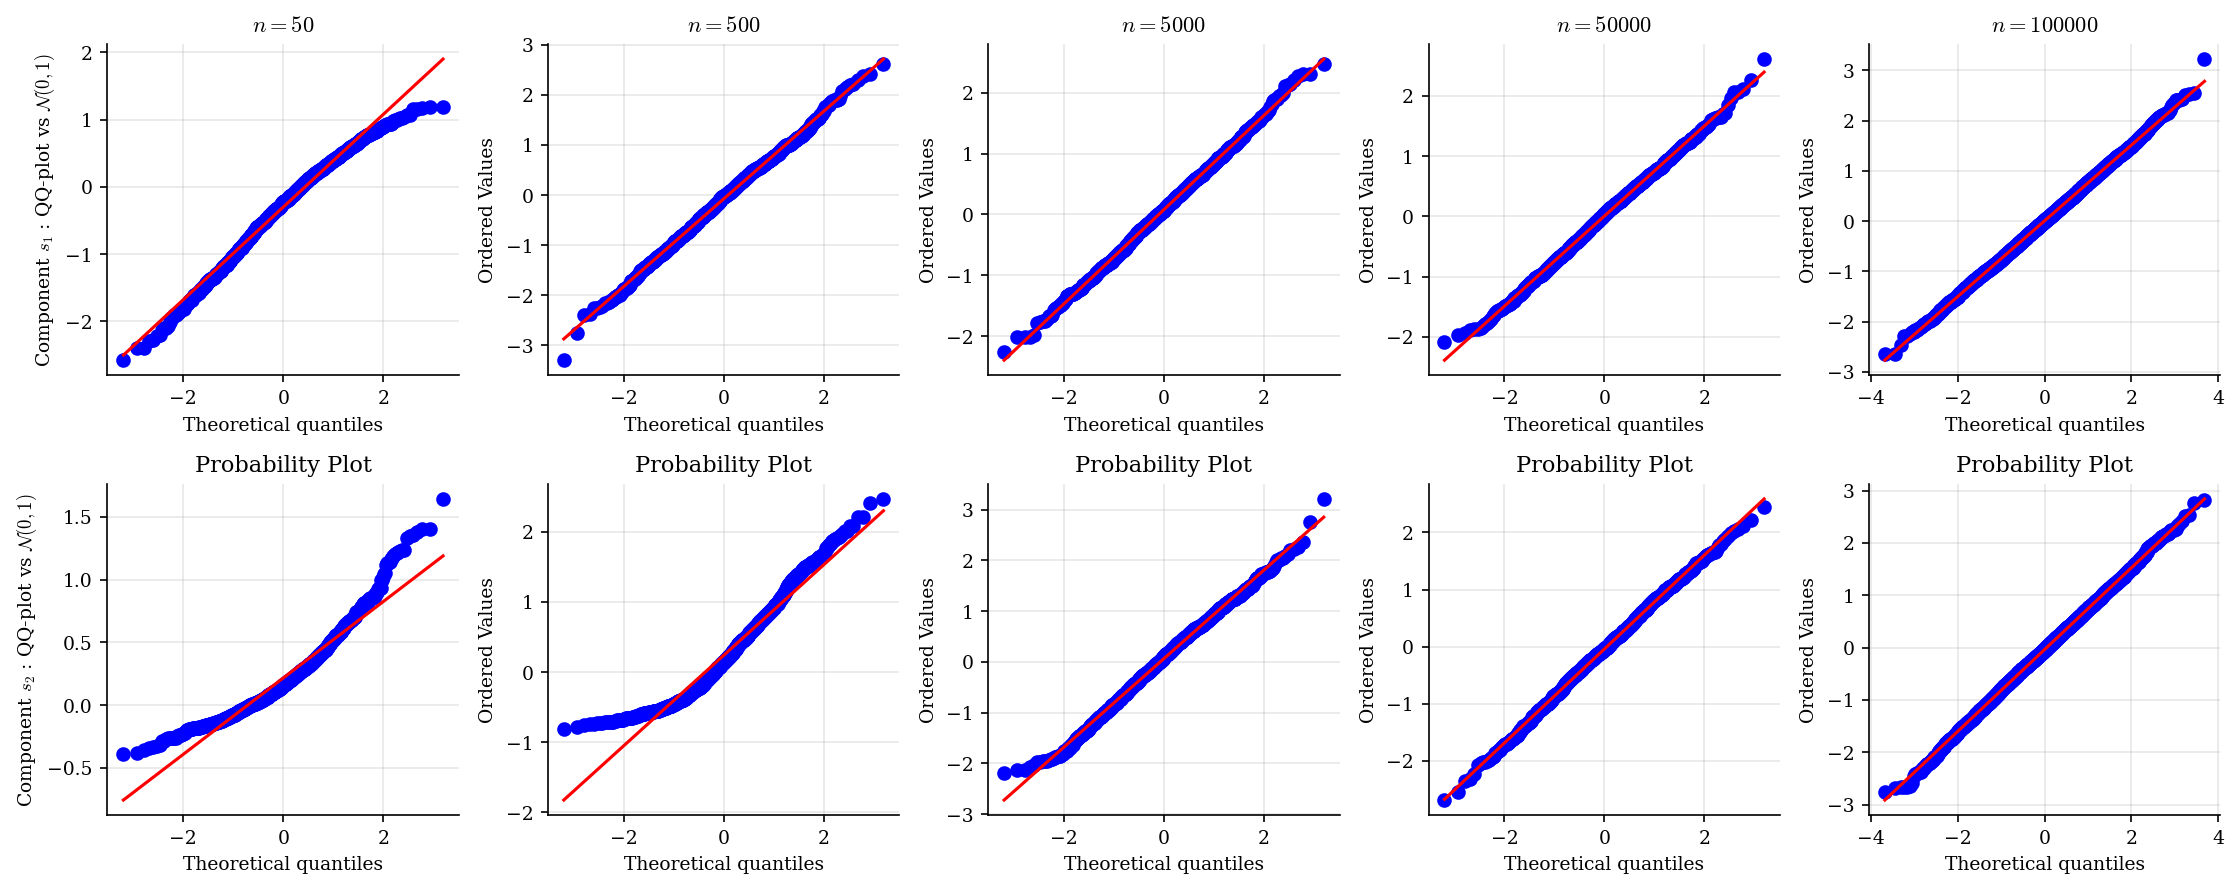

In [135]:
sizes = [50, 500, 5000, 50000, 100000]

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 9
})

fig, axes = plt.subplots(2, len(sizes), figsize=(3*len(sizes), 6), dpi=150)

for j, n in enumerate(sizes):

    Z_white = np.loadtxt(f"tcl_results_{n}.csv", delimiter=",")

    for i in range(2):

        ax = axes[i, j]

        stats.probplot(
            Z_white[:, i],
            dist="norm",
            plot=ax
        )

        if i == 0:
            ax.set_title(rf"$n={n}$")

        if j == 0:
            ax.set_ylabel(rf"Component $s_{i+1}$ : QQ-plot vs $\mathcal{{N}}(0,1)$")

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("tcl_convergence.png", bbox_inches='tight')
plt.show()


True Sobol: [0.16666667 0.66666667 0.16666667]


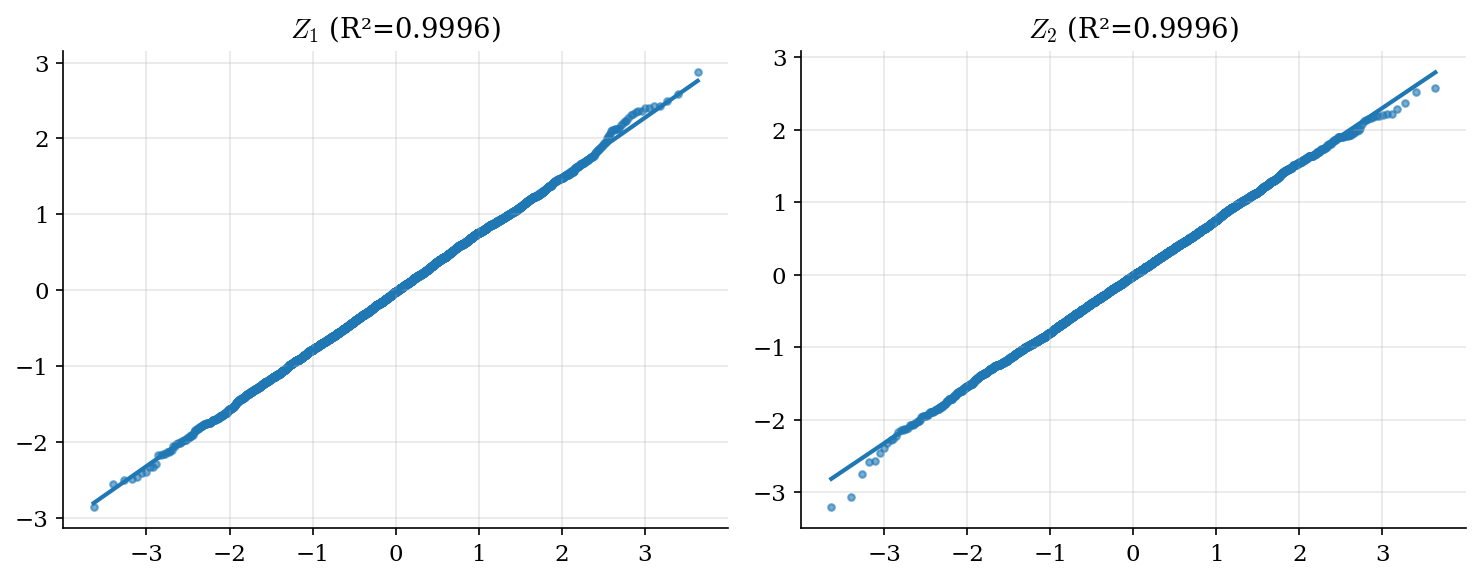

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(0)

# =====================================================
# MODEL : non linéaire centré
# =====================================================

def model(X):
    return X[:,0] * (X[:,1] > 0) + X[:,1]

def sample_X(size):
    return np.random.randn(size, 2)

# =====================================================
# Sobol exacts
# =====================================================

S_star = np.array([
    1/6,
    2/3,
    1/6
])

print("True Sobol:", S_star)

# =====================================================
# Möbius inverse
# =====================================================

M_inv = np.array([
    [1,0,0],
    [0,1,0],
    [1,1,1]
], dtype=float)

# =====================================================
# Projection matrix
# =====================================================

B = np.array([
    [1, -1, 0],
    [1, 1, -2]
], dtype=float)

Q, _ = np.linalg.qr(B.T)
P = Q.T

# =====================================================
# Pick-Freeze vectorisé
# =====================================================

def pick_freeze_vectorized(subset, X, Xp):

    X_new = X.copy()

    mask0 = subset == 0   # freeze X1 → resample X2
    mask1 = subset == 1   # freeze X2 → resample X1

    X_new[mask0, 1] = Xp[mask0, 1]
    X_new[mask1, 0] = Xp[mask1, 0]

    return model(X_new)

# =====================================================
# Estimation Sigma
# =====================================================

def sample_xi(n_samples=300000):

    xis = []

    for _ in range(n_samples):

        X = np.random.randn(2)
        Xp = np.random.randn(2)

        subset = np.random.choice([0,1,2])

        Y = X[0] * (X[1] > 0) + X[1]
        Y_pf = pick_freeze_vectorized(
            np.array([subset]),
            X.reshape(1,2),
            Xp.reshape(1,2)
        )[0]

        MS = M_inv @ S_star

        grad = Y * M_inv[subset] * (Y * MS[subset] - Y_pf)

        xis.append(grad)

    xis = np.array(xis)

    return np.cov(xis.T)

Sigma = sample_xi()

# =====================================================
# Matrice asymptotique
# =====================================================

Var = 3/2  # variance exacte

H = (Var/4) * np.array([
    [2,1,1],
    [1,2,1],
    [1,1,1]
])

H_T = P @ H @ P.T
H_T_inv = np.linalg.inv(H_T)

Sigma_T = P @ Sigma @ P.T
V = H_T_inv @ Sigma_T @ H_T_inv

# =====================================================
# Mirror descent vectorisé
# =====================================================

def mirror_descent_vectorized(n_runs=1000, n_iter=10000, eta0=10):

    S = np.ones((n_runs, 3)) / 3
    S_avg = np.zeros_like(S)

    m = np.zeros(n_runs)

    subsets = np.arange(3)
    probs = np.ones(3)/3

    for t in range(1, n_iter+1):

        X = sample_X(n_runs)
        Xp = sample_X(n_runs)

        subset = np.random.choice(subsets, size=n_runs, p=probs)

        Y = model(X)
        Y_pf = pick_freeze_vectorized(subset, X, Xp)

        # update mean
        m += (Y - m)/t

        MS = S @ M_inv.T

        grad = (
            Y[:,None]
            * M_inv[subset]
            * (Y[:,None] * MS[range(n_runs), subset][:,None]
               - Y_pf[:,None])
        )

        gamma_t = eta0 / t**0.501

        S *= np.exp(-gamma_t * grad)
        S /= S.sum(axis=1, keepdims=True)

        S_avg += (S - S_avg)/t

    return S_avg

# =====================================================
# Simulation TCL
# =====================================================

def run_many_fast(n_runs=5000, n_iter=200000):

    S_polyak = mirror_descent_vectorized(n_runs, n_iter)

    err = np.sqrt(n_iter) * (S_polyak - S_star)

    Z = err @ P.T

    return Z

Z = run_many_fast()

# =====================================================
# Whitening
# =====================================================

eigvals, eigvecs = np.linalg.eigh(V)
V_half = eigvecs @ np.diag(np.sqrt(eigvals))

Z_white = np.linalg.solve(V_half, Z.T).T

# =====================================================
# QQ plots propres
# =====================================================

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 11
})

fig, axes = plt.subplots(1, 2, figsize=(10,4), dpi=150)

for i in range(2):

    ax = axes[i]

    (osm, osr), (slope, intercept, r) = stats.probplot(
        Z_white[:, i],
        dist="norm"
    )

    ax.scatter(osm, osr, s=10, alpha=0.6)
    ax.plot(osm, slope*osm + intercept, linewidth=2)

    ax.set_title(rf"$Z_{i+1}$ (R²={r**2:.4f})")

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
